## Công thức cho Hidden Layer thứ l
$$H_t^{(l)} = \phi_l(H_t^{(l-1)} W_{xh}^{(l)} + H_{t-1}^{(l)} W_{hh}^{(l)} + b_h^{(l)}) $$

Trong đó $H_T^{(0)} = X_t$ là đầu vào của mạng. Tầng đầu ra chỉ dựa vào hidden layer cuối cùng:
$$O_t = \phi_o(H_t^{(L)} W_{ho} + b_o)$$

In [1]:
from d2l import torch as d2l
from torch import nn
import torch

In [5]:
class StackedRNNScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, num_layers, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.rnns = nn.Sequential(
            *[
                d2l.RNNScratch(
                    num_inputs=num_inputs if i == 0 else num_hiddens,
                    num_hiddens=num_hiddens,
                    sigma=sigma,
                )
                for i in range(num_layers)
            ]
        )

    def forward(self, inputs, H=None):
        outputs = inputs
        if H is None:
            H = [None] * len(self.rnns)
        for i in range(self.num_layers):
            outputs, H[i] = self.rnns[i](outputs, H[i])
            outputs = torch.stack(outputs, dim=0)
        return outputs, H

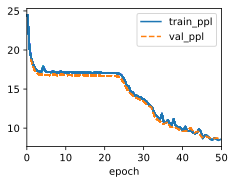

In [8]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn_block = StackedRNNScratch(num_inputs=len(data.vocab), num_hiddens=32, num_layers=2)
model = d2l.RNNLMScratch(rnn_block, vocab_size=len(data.vocab), lr=2)
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [13]:
class GRU(d2l.RNN):
    def __init__(self, num_inputs, num_hiddens, num_layers, dropout=1):
        d2l.Module.__init__(self)
        self.save_hyperparameters()
        self.rnn = nn.GRU(num_inputs, num_hiddens, num_layers, dropout=dropout)

    def forward(self, inputs, H=None):
        return self.rnn(inputs, H)

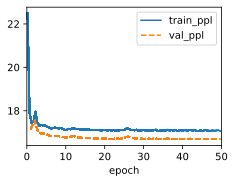

In [14]:
model = d2l.RNNLM(GRU(num_inputs=len(data.vocab), num_hiddens=32, num_layers=2), vocab_size=len(data.vocab), lr=2)
trainer.fit(model, data)

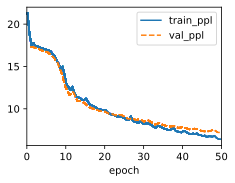

In [15]:
model = GRU(num_inputs=len(data.vocab), num_hiddens=32, num_layers=2, dropout=0)
model = d2l.RNNLM(model, vocab_size=len(data.vocab), lr=2)
trainer.fit(model, data)